# Прогноз упоминаний Сталина на «России 1»

Расчёт выполнен 4 октября 2026 года по локальной выгрузке, которая заканчивается 2 октября 2026 года (Europe/Moscow). Лучший результат по выбранной метрике дала M4: **28,60 совпадения фамилии за 03.10–02.11.2026**, округлённо **29**, с **80%-м прогнозным интервалом 15–45** и **95%-м интервалом 10–59**. Медиана равна 26. Среднее используется как точечный прогноз при квадратичной функции потерь.


In [1]:
from pathlib import Path
import sys, os
os.environ['OPENBLAS_NUM_THREADS']='1'
os.environ['OMP_NUM_THREADS']='1'
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'data_collection/data/bigquery_upload/tv_daily_coverage.jsonl.gz').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Откройте тетрадку внутри папки проекта forecasting с локальной ТВ-выгрузкой.')
sys.path.insert(0, str(ROOT/'analysis/deps'))
sys.path.insert(0, str(ROOT/'analysis'))
import numpy as np, pandas as pd
from IPython.display import display, Image
OUT=ROOT/'output/stalin_russia1'
print('Папка проекта:',ROOT)


Папка проекта: C:\Users\user\Documents\forecasting


## 1. Что именно прогнозируется

Содержательная цель: количество упоминаний Иосифа Сталина в эфире «России 1» за месяц. Доступная измеримая переменная: число токенов `Сталин`, `Сталина`, `Сталину`, `Сталиным`, `Сталине` без учёта регистра в автоматических расшифровках всех передач из сохранённого архива. Показатель считает каждое произнесённое/распознанное совпадение, а не число сюжетов или дней с упоминанием. Повторы в разных выпусках учитываются. «Сталинград» и «сталинский» не подходят под исходный шаблон.

**Это приближение к числу упоминаний конкретного человека.** Полная ручная разметка 2 351 контекста не проводилась. Выборочная проверка обнаружила ошибки распознавания: например, «в сталину» в развлекательной передаче 13.01.2024, вероятно, соответствует «в старину». Есть также название танка «Иосиф Сталин». Такие случаи остаются в исходном ряду; модели не превращают кандидатов в проверенные персональные упоминания. Прогноз относится к доступному корпусу, а не к доказанно полному суточному эфиру. Для строго персонального ряда потребуется разметка контекстов и повторный расчёт тем же кодом.

Поскольку запрос касается канала, используются все сохранённые программы: новости, политические ток-шоу, развлекательные передачи и прочие фрагменты. Фильтр «только новости» не добавлялся. Будущие политические события и изменения сетки вещания неизвестны и не вводились как будто наблюдаемые признаки.

Один месяц определён как промежуток после последней даты до той же даты следующего месяца: с 03.10.2026 по 02.11.2026 включительно, **31 день**. Суточные распределения моделируются совместно, затем суммируются в месячный итог. Месячные интервалы получены из сумм целых траекторий; складывать границы дневных интервалов было бы ошибкой.


## 2. Данные и пропуски

Локальный источник: `data_collection/data/bigquery_upload/tv_daily_coverage.jsonl.gz`; исходные передачи, статусы и контексты находятся в `data/tv.sqlite`. Для расчёта не требуются BigQuery или повторное скачивание текстов. Использован канал `RUSSIA1`.

Период: 01.01.2023–02.10.2026, всего **1 371 календарный день**. Имеются **1 327 пригодных наблюдений**, **44 дня исключены**. Пригодный день требует доступного перечня (`inventory_status == 200`) и всех расшифровок перечисленных передач (`coverage_status == observed_listed_broadcasts`). Из 44 дней 43 уже помечены в выгрузке как неполные; дополнительно исключён 07.10.2025: расшифровки есть, но перечень имеет статус 404. Это консервативный критерий полноты относительно архива.

За пригодные дни найдено **2 350 совпадений**; за все имеющиеся фрагменты, включая неполные дни, 2 351. Пропуски остаются `NaN`, не заменяются нулями. В динамической модели состояние продолжает двигаться в пропущенный день, но обновления по наблюдению нет. Частично доступные дневные количества также не используются как полные наблюдения.

Среднее по пригодным дням: **1.771**, дисперсия: **8.783**, доля нулевых дней: **46.1%**. Дисперсия значительно больше среднего. Часть избыточного разброса связана с разными программами, повторными выпусками, меняющимся уровнем и доступностью архива. NB полезна как модель этого разброса; это ещё не доказательство конкретного причинного механизма.

При исключении пропусков предполагается, что наблюдаемые дни достаточно представительны. Это предположение нельзя проверить полностью: сбои архива и смена объёма расшифровок могут быть связаны с содержанием передач. Число слов известно только после эфира, поэтому будущий фактический объём текстов не используется в качестве предиктора. Интервалы ниже не покрывают систематическую ошибку измерения или неизвестную неполноту архива.


## 3. Четыре последовательных расширения

### M1. Постоянная интенсивность: Gamma–Poisson

$$Y_t\mid\lambda\sim\mathrm{Poisson}(\lambda),\qquad \lambda\sim\mathrm{Gamma}(1,1).$$

Здесь второй параметр Gamma — rate. После $n$ пригодных дней:

$$\lambda\mid D\sim\mathrm{Gamma}\left(1+\sum y_t,\;1+n\right).$$

Это разумная базовая модель: все наблюдаемые дни одного канала считаются сопоставимыми. Она не учитывает календарь и изменения уровня. Параметр $\lambda$ интегрируется, поэтому даже при пуассоновском условном распределении прогнозный разброс не равен точно среднему. Для каждой будущей траектории берётся один общий draw $\lambda$, затем независимые условные дневные количества. Это сохраняет зависимость из-за общей неопределённой интенсивности.

### M2. M1 + дополнительная дневная дисперсия

$$Y_t\mid\mu,\kappa\sim\mathrm{NB}(\mu,\kappa),\qquad
\operatorname{Var}(Y_t\mid\mu,\kappa)=\mu+\mu^2/\kappa.$$

Представление Gamma–Poisson: $\Lambda_t\mid\mu,\kappa\sim\mathrm{Gamma}(\kappa,\kappa/\mu)$, затем $Y_t\sim\mathrm{Poisson}(\Lambda_t)$. В M1 постоянен общий уровень; в M2 вокруг него допускаются дополнительные дневные колебания. При $\kappa\to\infty$ условное распределение приближается к Poisson.

Priors: $\log\mu\sim N(\log2,1.5^2)$, $\log\kappa\sim N(0,1.5^2)$. Иные priors относительно сопряжённой M1 нужны для этой параметризации и указаны явно. Posterior M2 вычисляется методом Metropolis–Hastings из L3. Прогноз усредняется по posterior draws, а не строится только в оценке среднего параметра.

Ожидаемое улучшение: более реалистичные хвосты и интервалы при всплесках. Само добавление дисперсии почти не меняет средний уровень; улучшение точечной ошибки не гарантируется.

### M3. M2 + календарная иерархия и тренд

$$\log\mu_t=\alpha+\beta u_t+b_{m(t)}+c_{w(t)}.$$

$u_t$ — время в годах, центрированное на среднем дне обучающего периода. $m(t)$ — месяц года, $w(t)$ — день недели. Для идентификации эффекты месяцев и дней недели имеют нулевую сумму. Ортонормированные контрасты реализуют это ограничение.

Priors: $\alpha\sim N(\log2,1.5^2)$, $\beta\sim N(0,0.5^2)$; календарные контрасты имеют общий внутри группы prior $N(0,0.4^2)$; $\log\kappa\sim N(0,1.5^2)$. Это частичное объединение: эффекты редких или шумных групп стягиваются к общему уровню. Масштабы 0,4 фиксированы, а не оценены как неизвестные гиперпараметры. Иерархия организована по календарным группам одного канала; данные других каналов не подмешиваются.

Решение из L4 адаптировано к счётным данным. Тренд нужен, поскольку постоянная интенсивность усредняет высокий исторический уровень вместе с более низкими недавними значениями. Календарь может отражать регулярную сетку передач и сезонные изменения. Posterior M3 также вычисляется Metropolis–Hastings. Ни будущие количества, ни будущие объёмы расшифровок не входят в признаки.

### M4. M3 + меняющийся скрытый уровень

$$\log\mu_t=\alpha+\beta u_t+b_{m(t)}+c_{w(t)}+\ell_t,$$
$$\ell_t=\ell_{t-1}+\varepsilon_t,\quad \varepsilon_t\sim N(0,q^2),\quad \ell_0\sim N(0,0.3^2).$$

Здесь появляется модель движения скрытого состояния и отдельная NB-модель наблюдения, как в L5. Нелинейная связь и счётные наблюдения требуют фильтра частиц вместо точного линейного Gaussian Kalman filter. Фильтр выполняет шаг движения, перевзвешивание по вероятности наблюдения и systematic resampling при ESS ниже половины числа частиц. Без resampling предыдущие веса сохраняются.

Для прогноза состояние движется вперёд без обновления по неизвестным наблюдениям. Случайное блуждание имеет нулевое среднее приращение в логарифме; неопределённость состояния растёт. В шкале количества ожидание включает эффект экспоненты, поэтому его нельзя получить просто экспонентой среднего состояния.

**Вычислительное приближение M4:** используется модульная смесь фильтров, условных на 128 draws статических параметров из M3; в каждом фильтре 64 частицы состояния, всего 8 192. Веса между статическими draws остаются равными. Это условный/модульный подход, а не полный совместный Bayesian posterior всех статических параметров и состояний. Статические параметры оцениваются на том же прошлом, на котором фильтруются состояния; фильтр здесь нужен для условной оценки состояния, а не для повторного независимого обновления статических параметров. При полном совместном анализе результаты и интервалы могут измениться.

$q$ выбран по среднему месячному CRPS на полностью наблюдаемых development-месяцах июня–декабря 2024 года из сетки $0;0.03;0.07;0.15$. Выбрано **$q=0.03$**. Development-прогнозы также используют только прошлые данные. Октябрь 2024 года неполон и в месячный критерий не входит. Тестовые месяцы 2025–2026 годов не использовались для выбора $q$.


## 4. Как выполнена оценка

Проведён expanding-window backtest: **21 точка прогнозирования** перед началом каждого месяца с января 2025 по сентябрь 2026. Для каждой точки все модели заново обучаются на доступных пригодных днях строго до начала месяца; затем сразу прогнозируется весь следующий месяц, без обновления внутри него. Подход отвечает горизонту задачи, в отличие от оценки однодневных прогнозов с ежедневным переобучением.

**Дневные метрики:** 626 наблюдаемых тестовых дней. Для всех четырёх моделей используются одинаковые дни. Прогнозы для пропусков строятся, но не оцениваются.

**Основная месячная оценка:** 16 полностью наблюдаемых месяцев. Месяцы 2025-01, 2025-10, 2025-11, 2026-03, 2026-04 исключены из неё. Для них отдельно сохранены результаты суммы только наблюдаемых дней в `backtest_by_origin.csv`; такие суммы не выдаются за полный месячный итог.

Основной критерий выбора — **CRPS месячного распределения**, поскольку задача включает прогноз количества и его неопределённость. Для случайных величин $X,X'$ из прогнозного распределения:

$$\operatorname{CRPS}(F,y)=E|X-y|-\tfrac12E|X-X'|.$$

CRPS вычисляется по траекториям без подбора границ после наблюдения результата. Меньше лучше; единица измерения такая же, как у количества. Дополнительно вычислены RMSE и MAE для posterior predictive mean, отрицательный log score (NLL) дневного количества, покрытие и ширина 80%/95% интервалов, randomized PIT для дискретных прогнозов. Brier score не применяется к самому счётному исходу.

Для каждого backtest используется 6 000 траекторий; для финального прогноза — 30 000. Общие параметры и состояние сохраняются внутри траектории, поэтому месячный разброс учитывает зависимость между будущими днями.

Это **ретроспективный pseudo-out-of-sample backtest по текущему снимку расшифровок**. Исторические версии архива и время фактической публикации каждого текста не восстановлены. Схема обучения исключает будущие исходы, но не доказывает, что такой же корпус был доступен исследователю в реальном времени на каждой старой дате. M4 выбирается среди четырёх заранее заданных моделей по этому тесту; отдельного второго теста после выбора победителя нет.


## Код четырёх моделей

Следующая ячейка содержит все определения; затем расчёт запускается заново на локальном источнике.

In [2]:
"""Four nested count forecasting models. Only historical observations enter a fit.

Requires numpy, pandas, scipy and matplotlib. Optional project-local deps supported.
Models 2/3 use exact-posterior independent Metropolis-Hastings, with a Laplace
approximation used only to construct proposals. Model 4 is a modular particle
filter: static parameters are sampled from model 3, then held fixed per particle.
Its dynamic update is conditional on these static draws (not full joint Bayes).
"""
from pathlib import Path
import sys, json, gzip, hashlib, time
# Зависимости подключены в первой ячейке
import numpy as np
import pandas as pd
from scipy.special import gammaln, digamma, logsumexp, expit
from scipy.optimize import minimize
from scipy.stats import multivariate_t, norm, rankdata, t as student_t
from scipy.linalg import helmert

# ROOT определён в первой ячейке
BASE=ROOT/'data_collection'
OUT=ROOT/'output/stalin_russia1'
OUT.mkdir(parents=True,exist_ok=True)
SEED=20261004
NAMES={'M1':'Gamma-Poisson: постоянный уровень',
       'M2':'Negative binomial: дополнительная дисперсия',
       'M3':'NB: календарная иерархия и тренд',
       'M4':'NB: календарь, тренд и динамический уровень'}

def load_data():
    p=BASE/'data/bigquery_upload/tv_daily_coverage.jsonl.gz'
    with gzip.open(p,'rt',encoding='utf-8') as f:
        d=pd.DataFrame(json.loads(line) for line in f)
    d=d[d.channel=='RUSSIA1'].copy().sort_values('day')
    d['date']=pd.to_datetime(d.day)
    d['observed']=(d.coverage_status=='observed_listed_broadcasts') & (d.inventory_status=='200')
    d['y']=d.stalin_candidates.where(d.observed)
    assert len(d)==len(pd.date_range(d.date.min(),d.date.max()))
    assert d.date.is_unique and d.y.dropna().ge(0).all()
    d.to_csv(OUT/'daily_data.csv',index=False,encoding='utf-8-sig')
    return d, hashlib.sha256(p.read_bytes()).hexdigest()

def nb_logpmf(y,mu,k):
    return (gammaln(y+k)-gammaln(k)-gammaln(y+1)+k*(np.log(k)-np.log(k+mu))
            +y*(np.log(mu)-np.log(k+mu)))

def design(dates,calendar=False,center=0):
    dates=pd.DatetimeIndex(dates)
    if not calendar:return np.ones((len(dates),1))
    years=np.asarray((dates-pd.Timestamp('2023-01-01')).days)/365.25-center
    # Orthonormal contrasts give exactly sum-zero population effects.
    month=helmert(12,full=False).T[dates.month-1]
    dow=helmert(7,full=False).T[dates.dayofweek]
    return np.column_stack([np.ones(len(dates)),years,month,dow])

def posterior_problem(d,calendar):
    ok=d.observed.to_numpy()
    dates=d.date[ok]
    center=float(np.mean((dates-pd.Timestamp('2023-01-01')).dt.days)/365.25) if calendar else 0
    X=design(dates,calendar,center)
    y=d.y[ok].to_numpy(float)
    sd=np.array([1.5,.5]+[.4]*17+[1.5]) if calendar else np.array([1.5,1.5])
    prior=np.zeros(len(sd));prior[0]=np.log(2)
    initial=prior.copy();initial[0]=np.log(max(y.mean(),.1));initial[-1]=np.log(.7)
    fact=gammaln(y+1)
    def fun(theta):
        eta=X@theta[:-1]
        if np.max(np.abs(eta))>35 or abs(theta[-1])>15:
            return 1e100,np.zeros_like(theta)
        mu=np.exp(eta);k=np.exp(theta[-1]);den=mu+k
        ll=gammaln(y+k)-gammaln(k)-fact+k*(theta[-1]-np.log(den))+y*(eta-np.log(den))
        g_eta=k*(y-mu)/den
        gk=k*(digamma(y+k)-digamma(k)+theta[-1]-np.log(den)+1-(k+y)/den)
        diff=(theta-prior)/sd
        grad=np.r_[X.T@g_eta,gk.sum()]-(theta-prior)/sd**2
        return float(-ll.sum()+.5*np.dot(diff,diff)),-grad
    return fun,initial,center

def diagnostics(chains):
    # Rank-normalized split Rhat, also folded, following the modern diagnostic.
    m,n,p=chains.shape
    half=n//2
    c=np.concatenate([chains[:,:half],chains[:,-half:]],axis=0)
    def rh(z):
        W=z.var(axis=1,ddof=1).mean(axis=0)
        B=z.shape[1]*z.mean(axis=1).var(axis=0,ddof=1)
        return np.sqrt(((z.shape[1]-1)/z.shape[1]*W+B/z.shape[1])/W)
    z=np.empty_like(c);fold=np.empty_like(c)
    for j in range(p):
        a=c[:,:,j];N=a.size
        z[:,:,j]=norm.ppf((rankdata(a.ravel()).reshape(a.shape)-.375)/(N+.25))
        a=np.abs(a-np.median(a))
        fold[:,:,j]=norm.ppf((rankdata(a.ravel()).reshape(a.shape)-.375)/(N+.25))
    rhat=np.maximum(rh(z),rh(fold))
    # Conservative per-chain autocorrelation ESS, aggregated over chains.
    ess=[]
    for j in range(p):
        total=0
        for a in chains[:,:,j]:
            a=a-a.mean();ft=np.fft.rfft(a,n=2*n)
            ac=np.fft.irfft(ft*np.conj(ft))[:n];ac=ac/ac[0]
            pairs=ac[1:-1:2]+ac[2::2]
            end=np.flatnonzero(pairs<0)
            positive=pairs[:end[0]] if len(end) else pairs
            total+=n/max(1,1+2*np.minimum.accumulate(positive).sum())
        ess.append(total)
    return float(rhat.max()),float(min(ess))

def fit_nb(d,calendar,seed,draws=1200,warm=300):
    fun,x0,center=posterior_problem(d,calendar)
    opt=minimize(fun,x0,jac=True,method='BFGS',options={'gtol':1e-6,'maxiter':350})
    # Build the local Hessian directly; do not trust the BFGS inverse approximation.
    x=opt.x;p=len(x);eps=1e-4
    H=np.column_stack([(fun(x+np.eye(p)[j]*eps)[1]-fun(x-np.eye(p)[j]*eps)[1])/(2*eps) for j in range(p)])
    eigen,U=np.linalg.eigh((H+H.T)/2)
    cov=(U/np.maximum(eigen,1e-4))@U.T
    proposal=multivariate_t(loc=x,shape=cov,df=8)
    rng=np.random.default_rng(seed)
    samples=np.empty((4,draws,p));accepted=[]
    # Batched proposal generation avoids sampling overhead inside MH.
    for chain in range(4):
        candidates=proposal.rvs(size=draws+warm,random_state=rng)
        q=proposal.logpdf(candidates)
        current=x.copy();target=-fun(current)[0]-float(proposal.logpdf(current));acc=0
        logu=np.log(rng.random(draws+warm))
        for i,candidate in enumerate(candidates):
            proposed=-fun(candidate)[0]-q[i]
            if logu[i]<proposed-target:
                current=candidate;target=proposed
                if i>=warm:acc+=1
            if i>=warm:samples[chain,i-warm]=current
        accepted.append(acc/draws)
    rhat,ess=diagnostics(samples)
    diag={'calendar':calendar,'n_train':int(d.observed.sum()),'max_rank_split_rhat':rhat,
          'min_autocorrelation_ess':ess,'acceptance':accepted,
          'gradient_max':float(abs(fun(x)[1]).max()),'optimizer_success':bool(opt.success),
          'draws_per_chain':draws,'warmup':warm,'center_years':center,
          'map':x.tolist()}
    if rhat>1.03 or ess<250:
        if draws<4800:return fit_nb(d,calendar,seed,draws*2,warm*2)
        raise RuntimeError(f'Unreliable posterior sampling: {diag}')
    return {'theta':samples.reshape(-1,p),'center':center,'calendar':calendar,'diagnostics':diag}

def static_predict(fit,dates,n,seed):
    rng=np.random.default_rng(seed)
    theta=fit['theta'][rng.integers(len(fit['theta']),size=n)]
    X=design(dates,fit['calendar'],fit['center'])
    mu=np.exp(theta[:,:-1]@X.T);k=np.exp(theta[:,-1,None])
    draws=rng.negative_binomial(k,k/(k+mu))
    return draws,mu.mean(axis=0),{'mu':mu,'k':k}

def filter_state(d,fit,q,particles=8192,seed=1):
    """Modular posterior mixture: filter separately conditional on static draws.

    128 static posterior draws, each with an independent state particle filter.
    Observations update states within each draw, not static-draw weights.
    Thus this is deliberately a cut/modular posterior, not exact full Bayes.
    """
    rng=np.random.default_rng(seed)
    groups=128;per=max(32,particles//groups)
    theta=fit['theta'][rng.integers(len(fit['theta']),size=groups)]
    X=design(d.date,True,fit['center']);base=theta[:,:-1]@X.T
    k=np.exp(theta[:,-1,None])
    state=rng.normal(0,.3,(groups,per))
    logweights=np.full((groups,per),-np.log(per))
    miness=[];meaness=[]
    for i,y in enumerate(d.y):
        state+=rng.normal(0,q,state.shape)
        if np.isfinite(y):
            mu=np.exp(base[:,i,None]+state)
            lw=logweights+nb_logpmf(y,mu,k)
            logweights=lw-logsumexp(lw,axis=1,keepdims=True)
            w=np.exp(logweights)
            ess=1/(w*w).sum(axis=1)
            miness.append(float(ess.min()));meaness.append(float(ess.mean()))
            # Resample only concentrated groups; preserve weights otherwise.
            resample=np.flatnonzero(ess<per/2)
            for g in resample:
                u=(rng.random()+np.arange(per))/per
                cdf=w[g].cumsum();cdf[-1]=1
                state[g]=state[g,np.searchsorted(cdf,u)]
                logweights[g]=-np.log(per)
    # Final resampling produces equally weighted draws from each filtering belief.
    for g in range(groups):
        u=(rng.random()+np.arange(per))/per
        cdf=np.exp(logweights[g]).cumsum();cdf[-1]=1
        state[g]=state[g,np.searchsorted(cdf,u)]
    return theta,state,{'groups':groups,'particles_per_group':per,'q':q,
                       'min_pre_resampling_ess':min(miness),
                       'mean_pre_resampling_ess':float(np.mean(meaness))}

def dynamic_predict(d,fit,dates,q,n,seed,particles=8192):
    theta,state,diag=filter_state(d,fit,q,particles,seed)
    rng=np.random.default_rng(seed+100000)
    g=rng.integers(len(theta),size=n);j=rng.integers(state.shape[1],size=n)
    level=state[g,j].copy();theta=theta[g]
    X=design(dates,True,fit['center']);base=theta[:,:-1]@X.T
    k=np.exp(theta[:,-1,None]);mu=np.empty((n,len(dates)));draws=np.empty_like(mu,dtype=int)
    for i in range(len(dates)):
        level+=rng.normal(0,q,n)
        mu[:,i]=np.exp(base[:,i]+level)
        draws[:,i]=rng.negative_binomial(k[:,0],k[:,0]/(k[:,0]+mu[:,i]))
    return draws,mu.mean(axis=0),{'mu':mu,'k':k},diag

def crps_sample(draws,y):
    draws=np.sort(np.asarray(draws),axis=0)
    n=len(draws);weights=(2*np.arange(1,n+1)-n-1)/n**2
    return np.abs(draws-y).mean(axis=0)-np.sum(weights[:,None]*draws,axis=0)

def score(draws,mean,y,distribution=None,seed=1):
    y=np.asarray(y,float);ok=np.isfinite(y)
    yy=y[ok].astype(int);s=draws[:,ok];m=mean[ok]
    result={'n_days':len(yy),'daily_mae':float(np.abs(m-yy).mean()),
            'daily_mse':float(((m-yy)**2).mean()),
            'daily_crps':float(crps_sample(s,yy).mean())}
    for level in [.8,.95]:
        a=(1-level)/2;lo,hi=np.quantile(s,[a,1-a],axis=0)
        result[f'daily_coverage_{int(100*level)}']=float(((yy>=lo)&(yy<=hi)).mean())
        result[f'daily_width_{int(100*level)}']=float((hi-lo).mean())
    rng=np.random.default_rng(seed)
    if distribution is not None:
        mu=distribution['mu'][:,ok];k=distribution.get('k')
        if k is not None:lp=nb_logpmf(yy[None,:],mu,k)
        else:lp=yy[None,:]*np.log(mu)-mu-gammaln(yy[None,:]+1)
        result['daily_nll']=float(-(logsumexp(lp,axis=0)-np.log(len(lp))).mean())
    lower=(s<yy).mean(axis=0);mass=(s==yy).mean(axis=0)
    pit=lower+rng.random(len(yy))*mass
    total=s.sum(axis=1);actual=int(yy.sum());point=float(m.sum())
    lo80,hi80=np.quantile(total,[.1,.9]);lo95,hi95=np.quantile(total,[.025,.975])
    result.update({'actual_sum_observed':actual,'predicted_sum_observed':point,
      'monthly_error':point-actual,'monthly_ae':abs(point-actual),'monthly_se':(point-actual)**2,
      'monthly_crps':float(crps_sample(total[:,None],np.array([actual]))[0]),
      'monthly_lo80':float(lo80),'monthly_hi80':float(hi80),'monthly_lo95':float(lo95),'monthly_hi95':float(hi95),
      'monthly_coverage80':bool(lo80<=actual<=hi80),'monthly_coverage95':bool(lo95<=actual<=hi95),
      'monthly_width80':float(hi80-lo80),'monthly_width95':float(hi95-lo95)})
    return result,pit

def forecast_set(train,dates,n,seed,q=.07,save=False):
    rng=np.random.default_rng(seed)
    a=1+train.y.sum();b=1+train.observed.sum()
    lam=rng.gamma(a,1/b,n);mu=np.repeat(lam[:,None],len(dates),axis=1)
    forecasts={'M1':(rng.poisson(mu),mu.mean(axis=0),{'mu':mu})}
    fit2=fit_nb(train,False,seed+2);fit3=fit_nb(train,True,seed+3)
    forecasts['M2']=static_predict(fit2,dates,n,seed+12)
    forecasts['M3']=static_predict(fit3,dates,n,seed+13)
    a,b,c,diag=dynamic_predict(train,fit3,dates,q,n,seed+14)
    forecasts['M4']=(a,b,c)
    diagnostics_out={'M2':fit2['diagnostics'],'M3':fit3['diagnostics'],'M4':diag}
    if save:
        np.savez_compressed(OUT/'posterior_samples.npz',M2=fit2['theta'],M3=fit3['theta'])
        (OUT/'final_diagnostics.json').write_text(json.dumps(diagnostics_out,ensure_ascii=False,indent=2),encoding='utf-8')
    return forecasts,diagnostics_out,fit3

def summarize(records):
    frame=pd.DataFrame(records)
    rows=[]
    for model,g in frame.groupby('model',sort=False):
        complete=g[g.n_days==g.horizon]
        weights=g.n_days.to_numpy()
        row={'model':model,'name':NAMES[model],'origins':len(g),'observed_test_days':int(g.n_days.sum()),
             'full_months':len(complete)}
        for col in ['daily_mae','daily_mse','daily_crps','daily_nll','daily_coverage_80','daily_coverage_95','daily_width_80','daily_width_95']:
            row[col]=float(np.average(g[col],weights=weights))
        row['daily_rmse']=np.sqrt(row.pop('daily_mse'))
        for col in ['monthly_ae','monthly_crps','monthly_coverage80','monthly_coverage95','monthly_width80','monthly_width95']:
            row[col]=float(complete[col].mean())
        row['monthly_rmse']=float(np.sqrt(complete.monthly_se.mean()))
        rows.append(row)
    return pd.DataFrame(rows)

def paired_comparisons(records):
    # Non-overlapping monthly windows; paired loss differences, lag-1 HAC variance.
    frame=pd.DataFrame(records);frame=frame[frame.n_days==frame.horizon]
    out=[]
    for a,b in [('M1','M2'),('M2','M3'),('M3','M4'),('M1','M4')]:
        A=frame[frame.model==a].set_index('origin');B=frame[frame.model==b].set_index('origin')
        for loss in ['monthly_se','monthly_crps']:
            diff=(A[loss]-B[loss]).to_numpy();N=len(diff);center=diff-diff.mean()
            gamma0=np.dot(center,center)/N;gamma1=np.dot(center[1:],center[:-1])/N
            variance=max(0,gamma0+gamma1)  # Bartlett weight for lag 1 is .5
            se=np.sqrt(variance/N)
            stat=diff.mean()/se if se else 0
            p=2*student_t.sf(abs(stat),df=N-1)
            rng=np.random.default_rng(SEED+N)
            # Circular moving-block bootstrap, two months per block.
            starts=rng.integers(0,N,size=(10000,(N+1)//2))
            inds=np.stack([starts,(starts+1)%N],axis=-1).reshape(10000,-1)[:,:N]
            means=diff[inds].mean(axis=1);lo,hi=np.quantile(means,[.025,.975])
            out.append({'earlier':a,'later':b,'loss':loss,'n_full_months':N,
              'mean_loss_improvement':float(diff.mean()),'DM_HAC_lag1':float(stat),
              'approx_p_two_sided':float(p),'block_bootstrap_lo95':float(lo),'block_bootstrap_hi95':float(hi)})
    return pd.DataFrame(out)

def main():
    started=time.time();d,source_hash=load_data()
    # Development uses 2024 only. Test: Jan 2025-Sep 2026, 21 monthly occasions.
    # No test month is used to tune q or the calendar priors.
    qs=[0.,.03,.07,.15]
    dev=[];devdiag=[]
    for fold,start in enumerate(pd.date_range('2024-06-01','2024-12-01',freq='MS')):
        end=start+pd.DateOffset(months=1)-pd.Timedelta(days=1)
        train=d[d.date<start];test=d[(d.date>=start)&(d.date<=end)]
        fit=fit_nb(train,True,SEED+100+fold)
        for q in qs:
            s,m,dist,diag=dynamic_predict(train,fit,test.date,q,3000,SEED+200+fold)
            result,_=score(s,m,test.y,dist,SEED+fold)
            dev.append({'origin':(start-pd.Timedelta(days=1)).date().isoformat(),'q':q,
                        'horizon':len(test),**result})
        print('development',start.date(), 'elapsed',round(time.time()-started),flush=True)
    devframe=pd.DataFrame(dev);devframe.to_csv(OUT/'development_scores.csv',index=False)
    complete=devframe[devframe.n_days==devframe.horizon]
    q=float(complete.groupby('q').monthly_crps.mean().idxmin())
    print('frozen q',q,flush=True)
    records=[];pits={m:[] for m in NAMES};diags=[];daily_records=[]
    for fold,start in enumerate(pd.date_range('2025-01-01','2026-09-01',freq='MS')):
        end=start+pd.DateOffset(months=1)-pd.Timedelta(days=1)
        train=d[d.date<start];test=d[(d.date>=start)&(d.date<=end)]
        forecasts,diagnostic,_=forecast_set(train,test.date,6000,SEED+1000+fold*20,q)
        diags.append({'origin':(start-pd.Timedelta(days=1)).date().isoformat(),**diagnostic})
        for model,(s,m,dist) in forecasts.items():
            result,pit=score(s,m,test.y,dist,SEED+3000+fold)
            records.append({'origin':(start-pd.Timedelta(days=1)).date().isoformat(),
                            'test_start':start.date().isoformat(),'test_end':end.date().isoformat(),
                            'model':model,'horizon':len(test),'train_days':int(train.observed.sum()),**result})
            pits[model].extend(pit.tolist())
            lo,hi=np.quantile(s,[.025,.975],axis=0)
            for date,y,point,low,high in zip(test.date,test.y,m,lo,hi):
                daily_records.append({'model':model,'date':date.date().isoformat(),
                                      'actual':y,'mean':point,'lo95':low,'hi95':high})
        pd.DataFrame(records).to_csv(OUT/'backtest_by_origin.csv',index=False)
        print('test',start.date(),'elapsed',round(time.time()-started),flush=True)
    summary=summarize(records);summary.to_csv(OUT/'evaluation.csv',index=False,encoding='utf-8-sig')
    paired_comparisons(records).to_csv(OUT/'model_comparisons.csv',index=False)
    pd.DataFrame(daily_records).to_csv(OUT/'backtest_daily.csv',index=False)
    (OUT/'backtest_diagnostics.json').write_text(json.dumps(diags,indent=2),encoding='utf-8')
    start=d.date.max()+pd.Timedelta(days=1)
    end=d.date.max()+pd.DateOffset(months=1)
    dates=pd.date_range(start,end)
    forecasts,_,fit=forecast_set(d,dates,30000,SEED+5000,q,True)
    future=[];monthly=[]
    for model,(s,m,dist) in forecasts.items():
        total=s.sum(axis=1);quant=np.quantile(total,[.025,.1,.5,.9,.975])
        monthly.append({'model':model,'name':NAMES[model],'start':start.date().isoformat(),
          'end':end.date().isoformat(),'days':len(dates),'mean':float(m.sum()),'median':float(quant[2]),
          'lo80':float(quant[1]),'hi80':float(quant[3]),'lo95':float(quant[0]),'hi95':float(quant[4]),
          'probability_ge_50':float((total>=50).mean())})
        quant_daily=np.quantile(s,[.025,.1,.5,.9,.975],axis=0)
        for i,date in enumerate(dates):
            future.append({'model':model,'date':date.date().isoformat(),'mean':m[i],
              'median':quant_daily[2,i],'lo80':quant_daily[1,i],'hi80':quant_daily[3,i],
              'lo95':quant_daily[0,i],'hi95':quant_daily[4,i]})
    np.savez_compressed(OUT/'forecast_paths.npz',dates=np.asarray(dates.strftime('%Y-%m-%d'),dtype='<U10'),
                        **{model:f[0] for model,f in forecasts.items()})
    pd.DataFrame(future).to_csv(OUT/'forecast_daily.csv',index=False,encoding='utf-8-sig')
    pd.DataFrame(monthly).to_csv(OUT/'forecast_month.csv',index=False,encoding='utf-8-sig')
    # Particle stability, held apart from predictive model selection.
    stability=[]
    for particles in [8192,32768]:
        for seed in [SEED+6000,SEED+6001,SEED+6002]:
            s,m,_,diag=dynamic_predict(d,fit,dates,q,15000,seed,particles)
            stability.append({'particles':particles,'seed':seed,'mean':float(m.sum()),
                              'lo95':float(np.quantile(s.sum(1),.025)),
                              'hi95':float(np.quantile(s.sum(1),.975)),**diag})
    pd.DataFrame(stability).to_csv(OUT/'particle_stability.csv',index=False)
    metadata={'source':str(BASE/'data/bigquery_upload/tv_daily_coverage.jsonl.gz'),
      'source_sha256':source_hash,'timezone':'Europe/Moscow','channel':'RUSSIA1',
      'count_definition':'Surname-token candidates in all archived ASR broadcasts, not fully disambiguated person mentions',
      'first_date':d.day.min(),'last_date':d.day.max(),'calendar_days':len(d),
      'observed_days':int(d.observed.sum()),'excluded_days':int((~d.observed).sum()),
      'sum_complete_days':int(d.y.sum()),'sum_all_available':int(d.stalin_candidates.sum()),
      'q_selected_on_development':q,'development':'2024-06 through 2024-12',
      'test':'2025-01 through 2026-09','test_origins':21,
      'primary_selection_metric':'Monthly CRPS on months with all days observed',
      'selected_model':str(summary.loc[summary.monthly_crps.idxmin(),'model']),
      'seed':SEED,'runtime_seconds':round(time.time()-started,1)}
    (OUT/'metadata.json').write_text(json.dumps(metadata,ensure_ascii=False,indent=2),encoding='utf-8')
    plots(d,summary,records,future,monthly,pits)
    print(summary.to_string(index=False),flush=True)
    print(pd.DataFrame(monthly).to_string(index=False),flush=True)
    print('DONE',metadata,flush=True)

def plots(d,summary,records,future,monthly,pits):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,
      'axes.spines.right':False,'figure.dpi':140,'savefig.dpi':180})
    colors={'M1':'#969696','M2':'#dc7c32','M3':'#396cb0','M4':'#247c68'}
    figs=OUT/'figures';figs.mkdir(exist_ok=True)
    f=pd.DataFrame(future);f['date']=pd.to_datetime(f.date)
    fig,ax=plt.subplots(figsize=(11,4.6))
    hist=d[d.date>='2026-07-01'];ax.plot(hist.date,hist.y,color='#444444',lw=1,label='Наблюдения')
    for model in NAMES:
        a=f[f.model==model];ax.plot(a.date,a['mean'],label=model,color=colors[model],lw=1.8)
    a=f[f.model=='M4'];ax.fill_between(a.date,a.lo95,a.hi95,color=colors['M4'],alpha=.14,label='M4: 95% прогнозный интервал')
    ax.axvline(pd.Timestamp('2026-10-02'),color='#777',ls='--',lw=1)
    ax.set(ylabel='Совпадения фамилии в день',title='Россия 1: прогноз на 03.10–02.11.2026')
    ax.legend(ncol=3,fontsize=8);fig.autofmt_xdate();fig.tight_layout();fig.savefig(figs/'daily_forecast.png');plt.close(fig)
    fig,axes=plt.subplots(1,2,figsize=(10,4))
    for ax,col,title in zip(axes,['monthly_rmse','monthly_crps'],['Ошибка месячного итога (RMSE)','Вероятностная ошибка (CRPS)']):
        ax.bar(summary.model,summary[col],color=[colors[x] for x in summary.model]);ax.set_title(title);ax.set_ylabel('Меньше лучше')
        for i,v in enumerate(summary[col]):ax.text(i,v,f'{v:.1f}',ha='center',va='bottom')
    fig.suptitle(f'Историческая проверка: {int(summary.full_months.iloc[0])} полностью наблюдаемых месяцев')
    fig.tight_layout();fig.savefig(figs/'evaluation.png');plt.close(fig)
    fig,axes=plt.subplots(1,4,figsize=(12,3),sharey=True)
    for ax,model in zip(axes,NAMES):
        ax.hist(pits[model],bins=np.linspace(0,1,11),density=True,color=colors[model],alpha=.8)
        ax.axhline(1,color='#333',ls='--',lw=1);ax.set_title(model);ax.set_xlabel('Randomized PIT')
    axes[0].set_ylabel('Плотность');fig.suptitle('Калибровка дневных распределений: ориентир — равномерность')
    fig.tight_layout();fig.savefig(figs/'pit.png');plt.close(fig)
    fig,ax=plt.subplots(figsize=(10,4.3))
    r=pd.DataFrame(records);full=r[r.n_days==r.horizon]
    actual=full[full.model=='M1'];ax.plot(pd.to_datetime(actual.test_start),actual.actual_sum_observed,'k.-',label='Факт',lw=2)
    for model in NAMES:
        a=full[full.model==model];ax.plot(pd.to_datetime(a.test_start),a.predicted_sum_observed,'o-',color=colors[model],label=model,ms=3)
    ax.set(ylabel='Совпадения за месяц',title='Месячные итоги: прогнозы сделаны до начала каждого месяца')
    ax.legend(ncol=5);fig.autofmt_xdate();fig.tight_layout();fig.savefig(figs/'backtest_months.png');plt.close(fig)




In [3]:
main()

development 2024-06-01 elapsed 1


development 2024-07-01 elapsed 3


development 2024-08-01 elapsed 5


development 2024-09-01 elapsed 6


development 2024-10-01 elapsed 8


...

test 2026-08-01 elapsed 42


test 2026-09-01 elapsed 44


model                                        name  origins  observed_test_days  full_months  daily_mae  daily_crps  daily_nll  daily_coverage_80  daily_coverage_95  daily_width_80  daily_width_95  daily_rmse  monthly_ae  monthly_crps  monthly_coverage80  monthly_coverage95  monthly_width80  monthly_width95  monthly_rmse
   M1           Gamma-Poisson: постоянный уровень       21                 626           16   1.847693    1.291005   2.288383           0.915335           0.936102        3.998403        5.000000    2.684254   20.434827     16.720217              0.2500              0.4375          20.0000        30.625000     23.860421
   M2 Negative binomial: дополнительная дисперсия       21                 626           16   1.850435    1.094071   1.643928           0.947284           0.984026        5.680990       10.483147    2.685220   20.500659     14.494496              0.5625              0.8125          42.6875        65.442187     23.939742
   M3            NB: календарная и

model                                        name      start        end  days      mean  median  lo80  hi80  lo95  hi95  probability_ge_50
   M1           Gamma-Poisson: постоянный уровень 2026-10-03 2026-11-02    31 54.881385    55.0  45.0  64.0  41.0  70.0           0.756300
   M2 Negative binomial: дополнительная дисперсия 2026-10-03 2026-11-02    31 55.007505    53.0  36.0  76.0  28.0  90.0           0.603500
   M3            NB: календарная иерархия и тренд 2026-10-03 2026-11-02    31 32.558268    31.0  19.0  47.0  15.0  58.0           0.076767
   M4 NB: календарь, тренд и динамический уровень 2026-10-03 2026-11-02    31 28.599963    26.0  15.0  45.0  10.0  59.0           0.061933


DONE {'source': 'C:\\Users\\user\\Documents\\forecasting\\forecasting_mentions\\forecasting_mentions\\data\\bigquery_upload\\tv_daily_coverage.jsonl.gz', 'source_sha256': '4a22416af5b3d5bb504080eeb4da71557553a28c719b0e875aad5fdf697af4f3', 'timezone': 'Europe/Moscow', 'channel': 'RUSSIA1', 'count_definition': 'Surname-token candidates in all archived ASR broadcasts, not fully disambiguated person mentions', 'first_date': '2023-01-01', 'last_date': '2026-10-02', 'calendar_days': 1371, 'observed_days': 1327, 'excluded_days': 44, 'sum_complete_days': 2350, 'sum_all_available': 2351, 'q_selected_on_development': 0.03, 'development': '2024-06 through 2024-12', 'test': '2025-01 through 2026-09', 'test_origins': 21, 'primary_selection_metric': 'Monthly CRPS on months with all days observed', 'selected_model': 'M4', 'seed': 20261004, 'runtime_seconds': 54.9}


## Таблицы исторической оценки

In [4]:
evaluation=pd.read_csv(OUT/'evaluation.csv')
display(evaluation)
display(pd.read_csv(OUT/'model_comparisons.csv'))

,model,name,origins,observed_test_days,full_months,daily_mae,daily_crps,daily_nll,daily_coverage_80,daily_coverage_95,daily_width_80,daily_width_95,daily_rmse,monthly_ae,monthly_crps,monthly_coverage80,monthly_coverage95,monthly_width80,monthly_width95,monthly_rmse
0,M1,Gamma-Poisson: постоянный уровень,21,626,16,1.847693,1.291005,2.288383,0.915335,0.936102,3.998403,5.000000,2.684254,20.434827,16.720217,0.2500,0.4375,20.0000,30.625000,23.860421
1,M2,Negative binomial: дополнительная дисперсия,21,626,16,1.850435,1.094071,1.643928,0.947284,0.984026,5.680990,10.483147,2.685220,20.500659,14.494496,0.5625,0.8125,42.6875,65.442187,23.939742
2,M3,NB: календарная иерархия и тренд,21,626,16,1.536620,1.032559,1.604800,0.908946,0.969649,3.797284,7.101038,2.598673,18.254520,13.379413,0.6250,0.8750,35.1875,54.751562,22.546370
3,M4,"NB: календарь, тренд и динамический уровень",21,626,16,1.543288,1.019301,1.592968,0.916933,0.974441,4.064537,7.719449,2.573571,15.147643,11.055824,0.8125,0.9375,45.5000,72.064062,19.183532


,earlier,later,loss,n_full_months,mean_loss_improvement,DM_HAC_lag1,approx_p_two_sided,block_bootstrap_lo95,block_bootstrap_hi95
0,M1,M2,monthly_se,16,-3.791570,-2.188656,0.044856,-7.403925,-0.776269
1,M1,M2,monthly_crps,16,2.225721,3.436975,0.003669,0.947490,3.377011
2,M2,M3,monthly_se,16,64.772465,0.260508,0.798015,-415.006029,543.271915
3,M2,M3,monthly_crps,16,1.115083,0.288625,0.776819,-6.131178,8.626063
4,M3,M4,monthly_se,16,140.330861,2.072522,0.055864,20.645356,281.575747
5,M3,M4,monthly_crps,16,2.323589,2.119998,0.051093,0.254297,4.548422
6,M1,M4,monthly_se,16,201.311756,0.996186,0.334960,-164.865251,602.752184
7,M1,M4,monthly_crps,16,5.664393,1.497570,0.154991,-1.008907,13.244078


## Месячный и дневной прогноз

In [5]:
display(pd.read_csv(OUT/'forecast_month.csv'))
display(pd.read_csv(OUT/'forecast_daily.csv').query("model=='M4'"))

,model,name,start,end,days,mean,median,lo80,hi80,lo95,hi95,probability_ge_50
0,M1,Gamma-Poisson: постоянный уровень,2026-10-03,2026-11-02,31,54.881385,55.0,45.0,64.0,41.0,70.0,0.756300
1,M2,Negative binomial: дополнительная дисперсия,2026-10-03,2026-11-02,31,55.007505,53.0,36.0,76.0,28.0,90.0,0.603500
2,M3,NB: календарная иерархия и тренд,2026-10-03,2026-11-02,31,32.558268,31.0,19.0,47.0,15.0,58.0,0.076767
3,M4,"NB: календарь, тренд и динамический уровень",2026-10-03,2026-11-02,31,28.599963,26.0,15.0,45.0,10.0,59.0,0.061933


,model,date,mean,median,lo80,hi80,lo95,hi95
93,M4,2026-10-03,0.316915,0.0,0.0,1.0,0.0,2.0
94,M4,2026-10-04,1.487024,1.0,0.0,4.0,0.0,8.0
95,M4,2026-10-05,1.183827,0.0,0.0,3.1,0.0,7.0
96,M4,2026-10-06,0.958896,0.0,0.0,3.0,0.0,6.0
97,M4,2026-10-07,0.951536,0.0,0.0,3.0,0.0,5.0
98,M4,2026-10-08,0.919364,0.0,0.0,3.0,0.0,5.0
99,M4,2026-10-09,0.834060,0.0,0.0,3.0,0.0,5.0
100,M4,2026-10-10,0.316381,0.0,0.0,1.0,0.0,2.0
101,M4,2026-10-11,1.484893,1.0,0.0,4.0,0.0,8.0
102,M4,2026-10-12,1.182272,0.0,0.0,3.0,0.0,6.0


## Графики проверки и прогноза

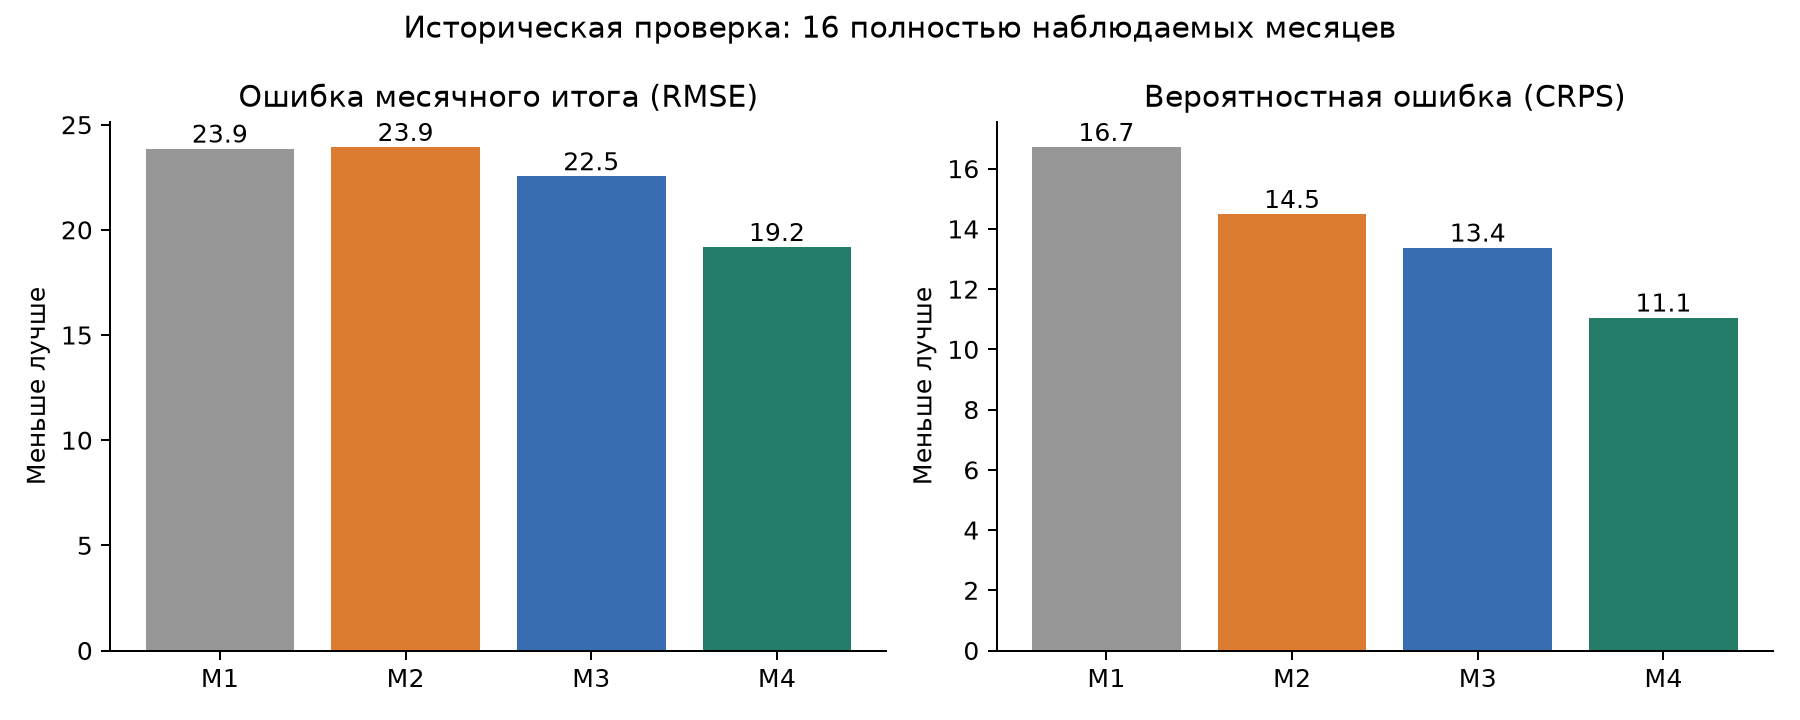

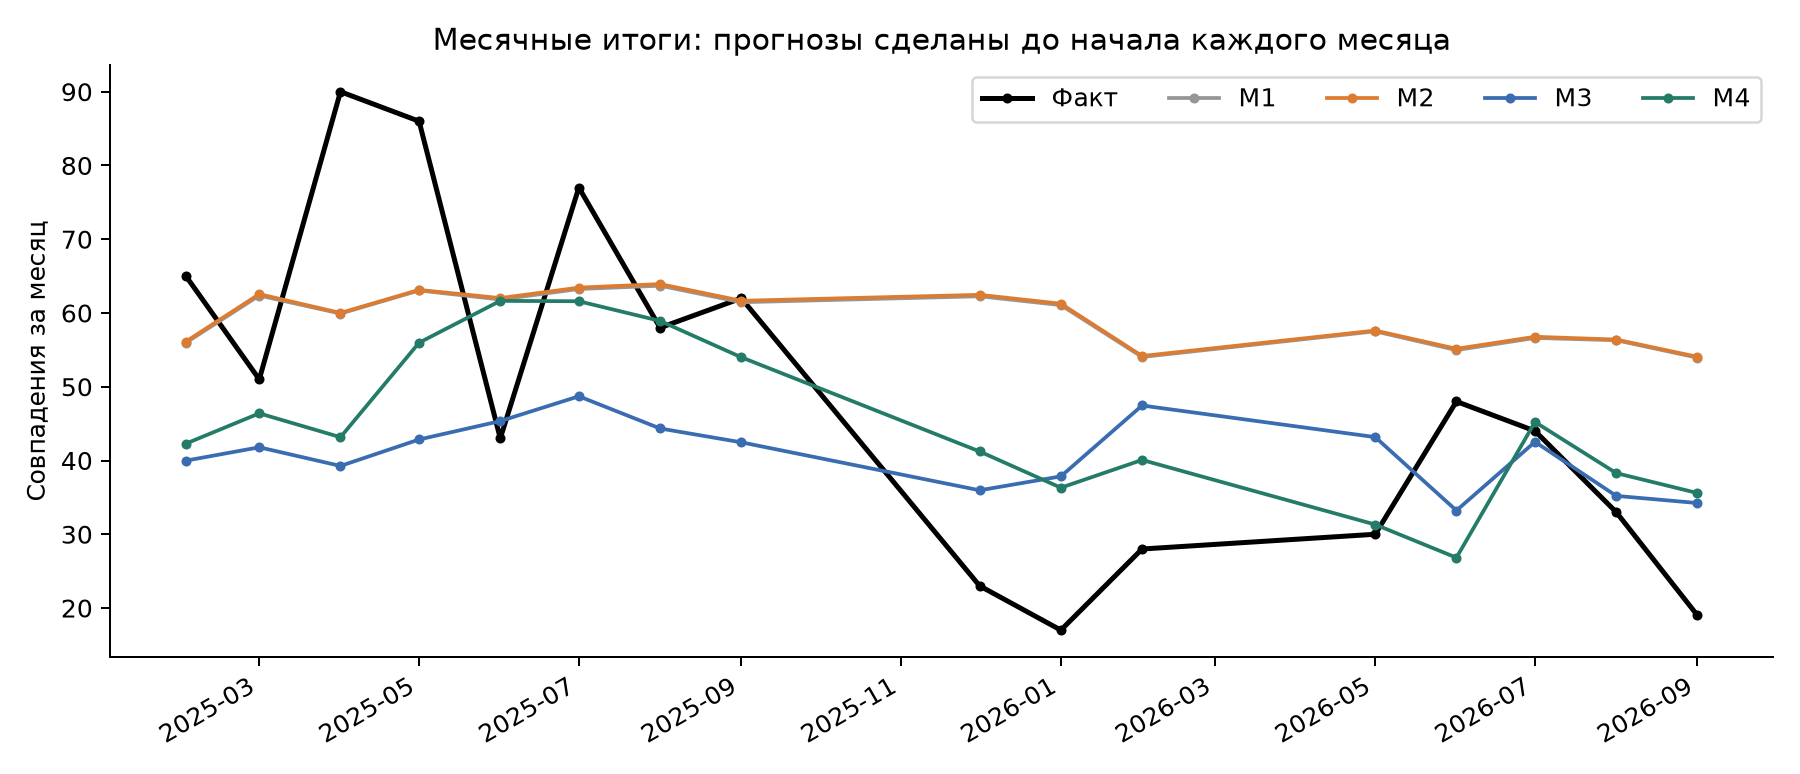

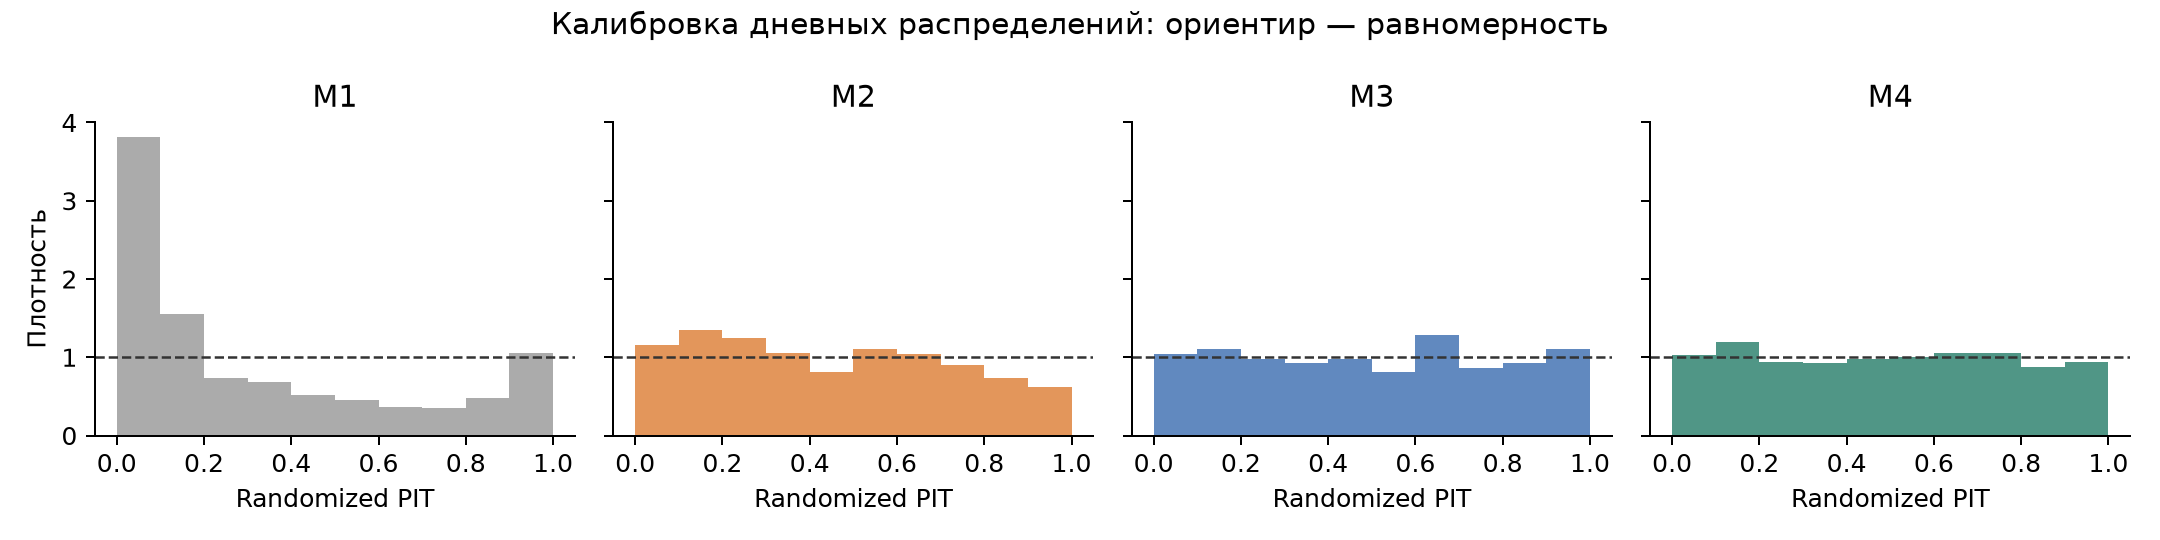

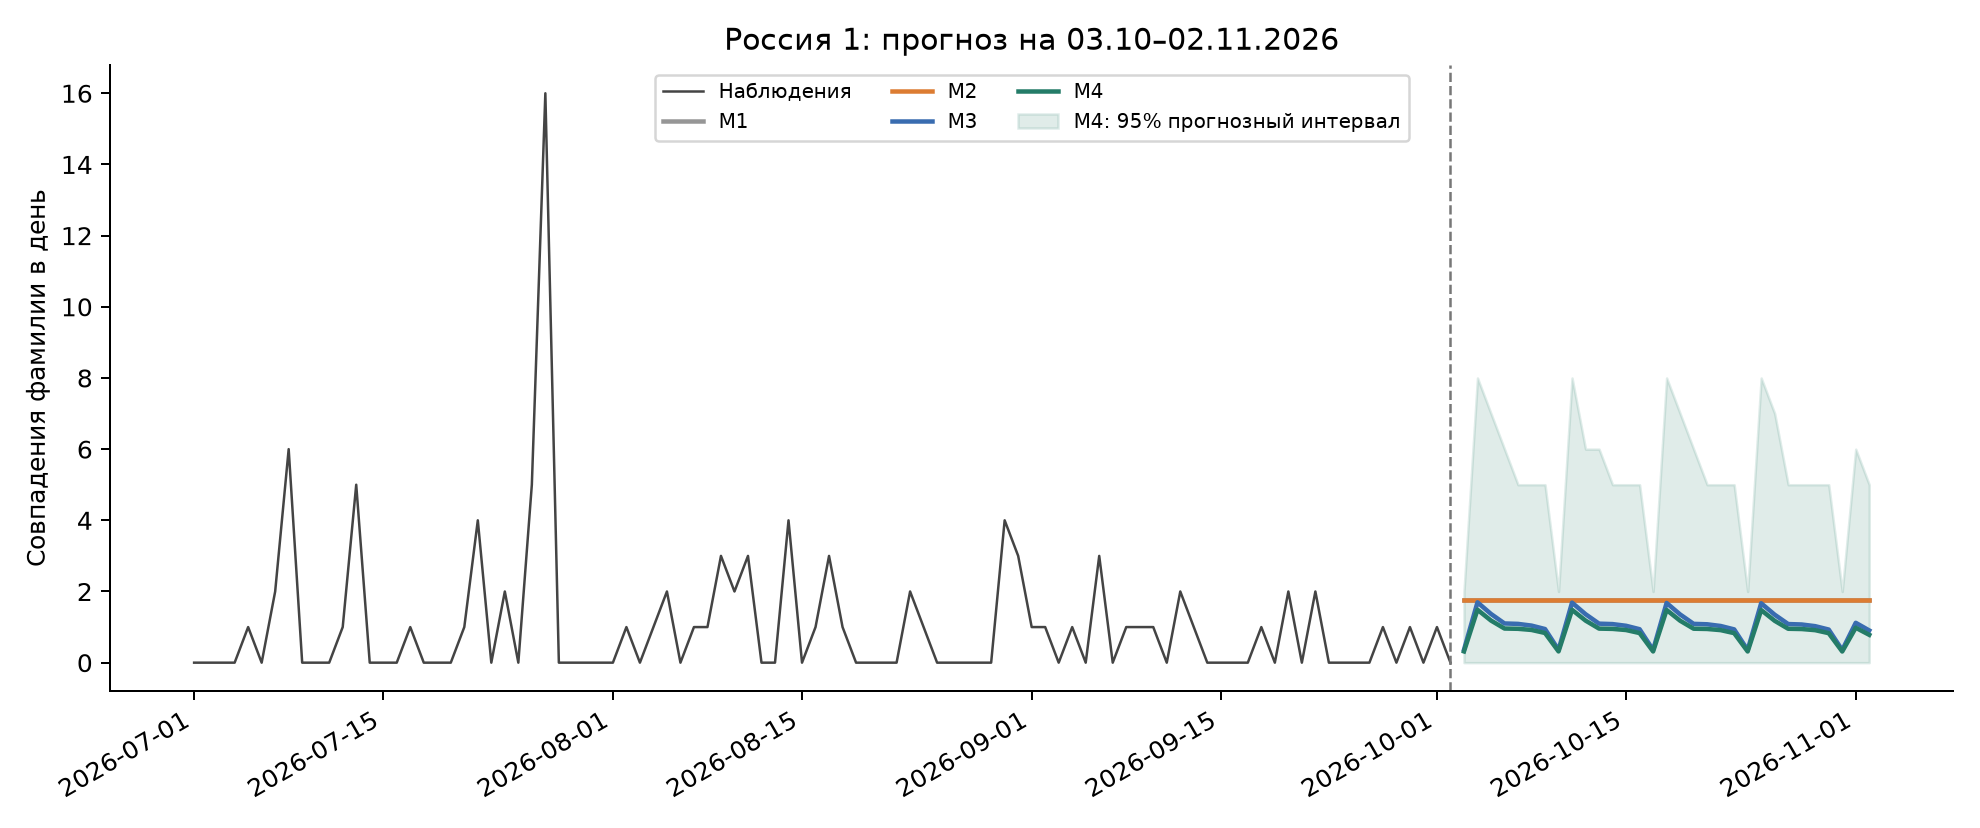

In [6]:
for name in ['evaluation.png','backtest_months.png','pit.png','daily_forecast.png']:
    display(Image(filename=str(OUT/'figures'/name)))

## Контроль вычислений

In [7]:
import runpy
runpy.run_path(str(ROOT/'analysis/verify_forecast.py'),run_name='__main__')
print((OUT/'final_diagnostics.json').read_text(encoding='utf-8'))
display(pd.read_csv(OUT/'particle_stability.csv'))

All forecast verification checks passed.
{
  "M2": {
    "calendar": false,
    "n_train": 1327,
    "max_rank_split_rhat": 1.000867805241819,
    "min_autocorrelation_ess": 3713.5162581129966,
    "acceptance": [
      0.9158333333333334,
      0.9258333333333333,
      0.9166666666666666,
      0.9325
    ],
    "gradient_max": 6.340892804157505e-07,
    "optimizer_success": true,
    "draws_per_chain": 1200,
    "warmup": 300,
    "center_years": 0,
    "map": [
      0.5715969102502867,
      -0.6673603753435625
    ]
  },
  "M3": {
    "calendar": true,
    "n_train": 1327,
    "max_rank_split_rhat": 1.0053953723448579,
    "min_autocorrelation_ess": 1492.8629503130428,
    "acceptance": [
      0.5308333333333334,
      0.5258333333333334,
      0.5483333333333333,
      0.5541666666666667
    ],
    "gradient_max": 8.564065190341807e-08,
    "optimizer_success": true,
    "draws_per_chain": 1200,
    "warmup": 300,
    "center_years": 1.8910811983203584,
    "map": [
      0.406

,particles,seed,mean,lo95,hi95,groups,particles_per_group,q,min_pre_resampling_ess,mean_pre_resampling_ess
0,8192,20267004,28.295213,10.0,57.0,128,64,0.03,3.177269,49.211051
1,8192,20267005,27.828794,10.0,57.0,128,64,0.03,3.316875,49.300951
2,8192,20267006,27.874079,10.0,57.0,128,64,0.03,5.684138,49.251059
3,32768,20267004,28.057056,10.0,58.0,128,256,0.03,13.436533,197.149459
4,32768,20267005,27.825223,10.0,56.0,128,256,0.03,10.623273,197.809052
5,32768,20267006,27.784661,10.0,56.0,128,256,0.03,10.210641,197.002266


## 5. Результаты

| Модель | RMSE месячного итога | CRPS месячного итога | Покрытие 80% | Покрытие 95% |
| --- | --- | --- | --- | --- |
| M1 | 23.86 | 16.72 | 25.0% | 43.8% |
| M2 | 23.94 | 14.49 | 56.2% | 81.2% |
| M3 | 22.55 | 13.38 | 62.5% | 87.5% |
| M4 | 19.18 | 11.06 | 81.2% | 93.8% |

По основному месячному CRPS каждое расширение улучшает предыдущую модель: **16,72 → 14,49 → 13,38 → 11,06**. M2 улучшает распределение и покрытие, но слегка ухудшает RMSE: 23,86 → 23,94. Поэтому утверждение «каждая модель лучше по всем метрикам» было бы неверным. Также M4 имеет немного больший дневной MAE, чем M3; выбор делается по месячной задаче.

M4 снижает месячный CRPS относительно M1 на **33.9%**, а RMSE на **19.6%** в этой исторической выборке. 80%-й месячный интервал M4 покрывает 13 из 16 результатов, 95%-й — 15 из 16. Это согласуется с заданными уровнями приблизительно, но 16 месяцев мало для точной проверки калибровки. У M1 95%-й интервал покрывает только 7 из 16 месячных итогов.

| Модель | Дневной RMSE | Дневной MAE | Дневной CRPS | Дневной NLL |
| --- | --- | --- | --- | --- |
| M1 | 2.684 | 1.848 | 1.291 | 2.288 |
| M2 | 2.685 | 1.85 | 1.094 | 1.644 |
| M3 | 2.599 | 1.537 | 1.033 | 1.605 |
| M4 | 2.574 | 1.543 | 1.019 | 1.593 |

![Оценка месячных прогнозов](figures/evaluation.png)

![Исторические месячные прогнозы](figures/backtest_months.png)

Randomized PIT рассчитывается как $F(y-1)+U\,P(Y=y)$, $U\sim U(0,1)$, по симулированным дневным распределениям. У M1 виден избыток низких PIT; M3/M4 ближе к равномерному ориентиру. Этот график показывает маргинальную дневную калибровку, но не подтверждает правильную зависимость дней или калибровку месячного итога.

![Randomized PIT](figures/pit.png)

### Значимость различий

Сравнения пар выполнены по потерям на одних и тех же 16 неперекрывающихся месяцах. Сохранены приблизительный Diebold–Mariano с HAC lag 1 и двусторонним t-ориентиром, а также circular moving-block bootstrap с блоками по два месяца. В таблице положительное снижение потерь означает преимущество более поздней модели.

| Переход | Снижение CRPS | p (приблизительный DM) | 95% блоковый bootstrap |
| --- | --- | --- | --- |
| M1 → M2 | 2.23 | 0.004 | 0.95…3.38 |
| M2 → M3 | 1.12 | 0.777 | -6.13…8.63 |
| M3 → M4 | 2.32 | 0.051 | 0.25…4.55 |
| M1 → M4 | 5.66 | 0.155 | -1.01…13.24 |

M2 убедительно улучшает CRPS относительно M1 в этой проверке. Для M3 против M2 убедительного преимущества не получено. У M4 против M3 результат пограничный: приблизительный DM даёт $p\approx0.051$, а двухмесячный bootstrap-интервал положителен. Разные проверки дают разные выводы возле порога 5%; при 16 месяцах, выбранной длине блока и нескольких сравнениях нельзя заявлять устойчивое доказанное преимущество M4. M4 имеет лучший средний результат, поэтому используется для итогового прогноза. Значения $p$ представлены без поправки за несколько сравнений.


## 6. Прогноз на 03.10–02.11.2026

| Модель | Среднее | Медиана | 80% интервал | 95% интервал |
| --- | --- | --- | --- | --- |
| M1 | 54.88 | 55 | 45–64 | 41–70 |
| M2 | 55.01 | 53 | 36–76 | 28–90 |
| M3 | 32.56 | 31 | 19–47 | 15–58 |
| M4 | 28.60 | 26 | 15–45 | 10–59 |

Все интервалы **прогнозные для фактического будущего количества**, а не интервалы только для неизвестного среднего. Точечный итог — среднее; округление до целого выполняется лишь для удобства чтения. Вероятность хотя бы 50 совпадений по M4 составляет **6.2%**. Это модельная вероятность для измеряемого ряда.

![Дневной прогноз](figures/daily_forecast.png)

M1/M2 сохраняют усреднённый за всю историю уровень и дают около 55 совпадений. M3 учитывает спад и календарь, прогнозируя около 33. M4 дополнительно корректирует уровень по недавним данным, прогнозируя около 29. Это интерпретация модели, а не установленная причина изменения внимания к Сталину.


## 7. Проверка вычислений и воспроизводимость

M2/M3: четыре MH-цепи, 300 warmup и 1 200 сохранённых draws на цепь; при недостаточных диагностических показателях код увеличивает длину. Локальная Laplace-аппроксимация используется только для предложения multivariate t в MH; принятие/отклонение считается по точной posterior плотности. Поэтому M2/M3 не подменены нормальной аппроксимацией posterior.

В финальной M3 максимальный rank-normalized split/folded R-hat **1.0054**, минимальный autocorrelation ESS **1493**. По всем тестовым подгонкам M2/M3 максимальный R-hat **1.0084**, минимальный ESS **1044**. ESS здесь оценён по автокорреляциям цепей, а не выдан за ArviZ bulk ESS.

Дополнительно M4 повторена на трёх seeds с 8 192 и 32 768 частицами. Средние месячные итоги составили **27.78–28.30**, нижние 95%-е границы 10, верхние 56–58; основной расчёт дал 28,60 и верхнюю границу 59. Размер частиц и случайные posterior draws вносят небольшую вычислительную погрешность. Поэтому итог сообщается как «около 29», а границы не следует трактовать как точные вне модели. Эта проверка контролирует Monte Carlo устойчивость, но не устраняет модульное приближение M4.

Автоматические проверки подтвердили NB-вероятности независимой реализацией SciPy, CRPS прямой попарной формулой, аналитические градиенты численным дифференцированием, даты обучения, одинаковые тестовые дни, неотрицательные целые траектории и месячные интервалы из сумм траекторий. Результат — `verification.json`.

Файлы:

- `stalin_russia1_forecast.ipynb`: выполненная тетрадка с кодом всех моделей, таблицами и графиками.
- `forecast_daily.csv`, `forecast_month.csv`: прогнозы четырёх моделей по дням и на весь месяц.
- `evaluation.csv`, `backtest_by_origin.csv`, `backtest_daily.csv`: оценка и исходные прогнозы исторической проверки.
- `development_scores.csv`: выбор $q$ только на development-периоде.
- `model_comparisons.csv`: статистические сравнения.
- `daily_data.csv`: использованный ряд и признаки доступности; пропуски сохранены.
- `posterior_samples.npz`, `forecast_paths.npz`: posterior draws M2/M3 и все финальные траектории.
- `final_diagnostics.json`, `backtest_diagnostics.json`, `particle_stability.csv`, `metadata.json`: диагностика и происхождение результатов.

Для повторного расчёта в проекте: `python analysis/stalin_models.py`, затем `python analysis/verify_forecast.py`. Тетрадка запускается через Run All и сама находит папку проекта. Для переноса нужны исходная суточная выгрузка и сохранённая структура папок. Анализ не изменяет вложенные Library-файлы и исходную ТВ-базу.

Версии зависимостей записаны в `requirements.txt`. Seed: **20261004**. SHA-256 входного сжатого файла: `4a22416af5b3d5bb504080eeb4da71557553a28c719b0e875aad5fdf697af4f3`.


## 8. Связь с предоставленными материалами

- **Forecasting Project Instructions**, стр. 1–2: целевая величина, горизонт, несколько моделей, оценка на нескольких событиях, сравнение и интерпретация. Два приложенных файла инструкций имеют одинаковый SHA-256; содержание совпадает. Указанные там обязанности по proposal, команде и презентации не трактуются как отдельный запрос пользователя на их создание.
- **L1 Forecast Evaluation A**, стр. 12, 18, 22–24: точечный, интервальный и вероятностный прогноз; калибровка, sharpness, proper scores и связь среднего с квадратичной потерей. CRPS — выбранная здесь конкретная реализация принципа proper scoring; он не приписывается отдельному слайду как показанная там формула.
- **L1 Forecast Evaluation B**: разделение качества решения и качества прогнозного распределения.
- **L2 Bayesian Mechanics B**, стр. 23–25: Bayesian update и недопустимость повторного счёта одного и того же сигнала как независимого свидетельства.
- **L3 Bayesian Computation**: posterior predictive averaging, Metropolis–Hastings и диагностика выборки; стр. 65–70: вероятностный score и неопределённость разницы scores.
- **ha15491_6191_3.ipynb**, Problem 3: NB-параметризация $\mu+\mu^2/\kappa$, сравнение с Poisson, posterior predictive score; предупреждение, что LOO по историческим дням не равно прогнозу будущего. Поэтому основной расчёт здесь использует хронологический backtest.
- **L4 Hierarchical Modeling**, стр. 17–27, и **S4_Hierarchical_Models.ipynb**, разделы 2 и 4: partial pooling и счётная иерархия. **HA4_Hierarchical_Models.ipynb** использован как дополнительный учебный контекст; его домашние задания не выполняются вместо пользовательского прогноза.
- **L5 Sequential Forecasting**, стр. 8–9, 37–42, 68–69, 79: модель состояния и наблюдения, оценка прогноза, доступного на соответствующую дату, фильтр частиц, сохранение весов без resampling и проверка устойчивости.

Первичный источник корпуса указан в README исходного проекта: [GDELT Visual Explorer: перечни и расшифровки ТВ](https://blog.gdeltproject.org/visual-explorer-quick-workflow-for-downloading-belarusian-russian-ukrainian-transcripts-translations/). Этот расчёт использует сохранённую локальную выгрузку и не подтверждает заново доступность внешнего архива.
